**Question 1:** What is the difference between K-Means and Hierarchical Clustering?
Provide a use case for each.


Difference between K-Means and Hierarchical Clustering

| K-Means Clustering                                                                                                | Hierarchical Clustering                                                                                             |
| ----------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| K-Means is a **partition-based clustering algorithm** that divides data into a predefined number of clusters (K). | Hierarchical Clustering is a **tree-based clustering algorithm** that builds a hierarchy of clusters.               |
| The number of clusters (**K**) must be specified before training.                                                 | The number of clusters does not need to be specified initially; it can be selected from the dendrogram.             |
| It assigns each data point to the nearest cluster centroid and updates centroids iteratively.                     | It merges smaller clusters into larger ones (agglomerative) or splits larger clusters into smaller ones (divisive). |
| It is faster and works well for large datasets.                                                                   | It is computationally more expensive and suitable for smaller datasets.                                             |
| It produces flat clusters without showing relationships between clusters.                                         | It produces a dendrogram that shows relationships and similarity between clusters.                                  |
| Sensitive to the initial choice of centroids and outliers.                                                        | Less dependent on initial conditions but can also be affected by noise and distance measures.                       |


Use Cases

1. K-Means Clustering Use Case:

Customer Segmentation in Marketing

A company can use K-Means to group customers based on features such as age, income, and purchasing behavior. The company can identify groups like high-value customers, budget shoppers, and occasional buyers to create targeted marketing strategies.

2. Hierarchical Clustering Use Case:

Gene Expression Analysis in Biology

Researchers can use hierarchical clustering to group genes with similar expression patterns. The dendrogram helps scientists understand relationships between genes and identify groups associated with specific diseases or biological functions.

**Question 2**: Explain the purpose of the Silhouette Score in evaluating clustering
algorithms.

Purpose of Silhouette Score in Evaluating Clustering Algorithms

The Silhouette Score is a clustering evaluation metric used to measure how well data points are grouped within their clusters. It evaluates both cluster cohesion (how similar data points are within the same cluster) and cluster separation (how different clusters are from each other).

The Silhouette Score for each data point is calculated using:

  - S=)b−a/max(a,b)

Where:

- a = Average distance between a data point and other points in the same cluster (measures cohesion).
- b = Average distance between the data point and points in the nearest neighboring cluster (measures separation).

Interpretation of Silhouette Score:
- Close to +1: Data points are well-clustered and far away from other clusters (good clustering).
- Around 0: Clusters overlap or data points are near the boundary between clusters.
- Negative values: Data points may have been assigned to the wrong cluster.

**Question 3**: What are the core parameters of DBSCAN, and how do they influence the
clustering process?

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups data points based on their density. Unlike K-Means, it does not require the number of clusters to be specified beforehand and can identify noise or outliers.

The two core parameters of DBSCAN are:

1. Epsilon (ε or eps)
- Definition: The maximum distance between two points for them to be considered neighbors.
- Influence on clustering:
   - A small ε value creates smaller, denser clusters and may classify many points as noise.
   - A large ε value may merge different clusters together and reduce the ability to detect separate groups.
- Choosing the right ε value is important for finding meaningful clusters.

2. Minimum Samples (MinPts)
- Definition: The minimum number of data points required within the ε-neighborhood for a point to be considered a core point.
- Influence on clustering:
   - A higher MinPts value creates stricter density requirements, resulting in fewer but denser clusters and more noise points.
    - A lower MinPts value allows more clusters to form but may create unstable or meaningless clusters

DBSCAN Point Types:
- Core Point: A point with at least MinPts neighbors within the ε radius; it forms the center of a cluster.
- Border Point: A point close to a core point but with fewer than MinPts neighbors; it joins the cluster.
- Noise Point: A point that does not belong to any cluster.    

**Question 4**: Why is feature scaling important when applying clustering algorithms like
K-Means and DBSCAN?


Importance of Feature Scaling in Clustering Algorithms

Feature scaling is important in clustering algorithms like K-Means and DBSCAN because these algorithms rely on distance calculations to determine similarity between data points. If features have different scales, features with larger values can dominate the distance measurement and negatively affect clustering results.

Why Feature Scaling is Needed:
 - Prevents Dominance of Large-Scale Features
    - Features with larger numerical ranges contribute more to distance calculations.
    - Example: In customer data, annual income (₹10,00,000) may dominate age (20–60 years) if scaling is not applied.

- Improves Cluster Formation
   - Scaling ensures that all features contribute equally to identifying clusters.
   - This leads to more meaningful and accurate grouping of data points.
- Improves K-Means Performance
   - K-Means uses Euclidean distance to assign points to the nearest centroid.
    - Without scaling, centroids may be influenced mainly by high-value features,     producing incorrect clusters.
- Improves DBSCAN Performance

    - DBSCAN uses distance-based density calculations using ε (epsilon).
   - Incorrect feature scales can change neighborhood distances and cause poor cluster detection or incorrect identification of noise points.    

**Question 5:** What is the Elbow Method in K-Means clustering and how does it help
determine the optimal number of clusters?


Elbow Method in K-Means Clustering

The Elbow Method is a technique used to determine the optimal number of clusters (K) in K-Means clustering by analyzing how the model’s error changes as K increases.

How it Works:
- Run K-Means clustering for different values of K (e.g., 1 to 10).
- For each K, compute the Within-Cluster Sum of Squares (WCSS), also called inertia.
    - WCSS measures how close data points are to their respective cluster centroids.
- Plot K vs WCSS on a graph.
- Observe the shape of the curve.

Why it is called the “Elbow” Method:
- As K increases, WCSS decreases because clusters become smaller and more specific.
- Initially, the decrease is steep.
- After a certain point, the improvement becomes minimal.
- The point where the curve starts to bend sharply like an elbow is considered the optimal K.

Interpretation:
- Before the elbow: Adding clusters significantly improves the model.
- At the elbow: Best balance between simplicity and accuracy.
- After the elbow: Adding more clusters gives little improvement and may lead to overfitting.

**Question 6:** Generate synthetic data using make_blobs(n_samples=300, centers=4),
apply KMeans clustering, and visualize the results with cluster centers.

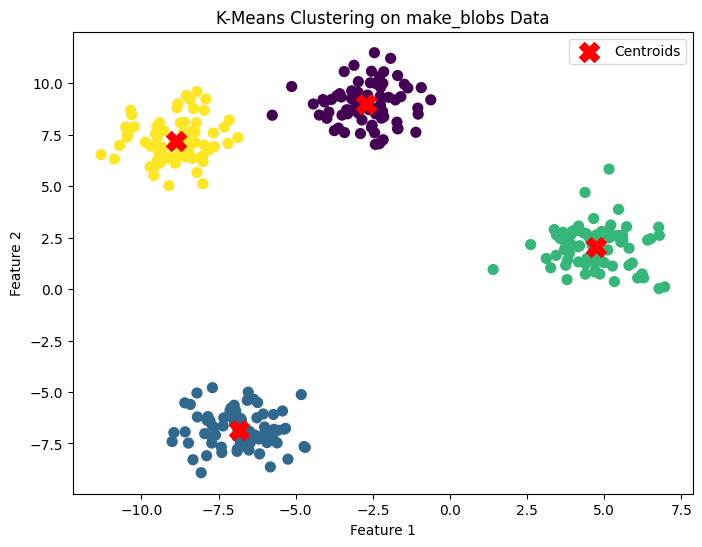

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Step 1: Generate synthetic data
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

# Step 2: Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

# Cluster labels and centroids
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Step 3: Visualization
plt.figure(figsize=(8, 6))

# Plot data points colored by cluster
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)

# Plot cluster centers
plt.scatter(centers[:, 0], centers[:, 1],
            c='red', marker='X', s=200, label='Centroids')

plt.title("K-Means Clustering on make_blobs Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

**Question 7**: Load the Wine dataset, apply StandardScaler , and then train a DBSCAN
model. Print the number of clusters found (excluding noise).

In [2]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# Step 1: Load dataset
wine = load_wine()
X = wine.data

# Step 2: Feature scaling (important for DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Step 4: Count number of clusters (excluding noise = -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Cluster labels:", np.unique(labels))
print("Number of clusters found (excluding noise):", n_clusters)

Cluster labels: [-1]
Number of clusters found (excluding noise): 0


**Question 8**: Generate moon-shaped synthetic data using
make_moons(n_samples=200, noise=0.1), apply DBSCAN, and highlight the outliers in
the plot.
(Include your Python code and output in the code box below.)

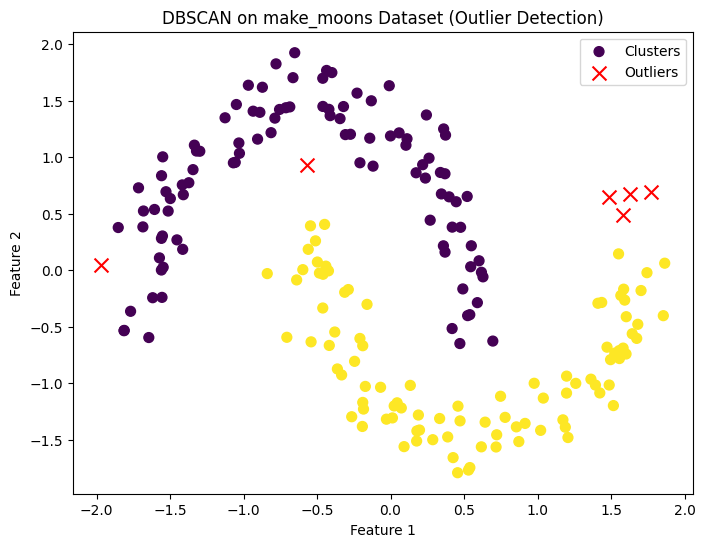

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Step 1: Generate moon-shaped data
X, y_true = make_moons(n_samples=200, noise=0.1, random_state=42)

# Step 2: Feature scaling (important for DBSCAN)
X_scaled = StandardScaler().fit_transform(X)

# Step 3: Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Step 4: Identify outliers (noise points = -1)
outliers = labels == -1

# Step 5: Visualization
plt.figure(figsize=(8, 6))

# Plot clusters
plt.scatter(X_scaled[~outliers, 0],
            X_scaled[~outliers, 1],
            c=labels[~outliers],
            cmap='viridis',
            s=50,
            label="Clusters")

# Plot outliers
plt.scatter(X_scaled[outliers, 0],
            X_scaled[outliers, 1],
            c='red',
            marker='x',
            s=100,
            label="Outliers")

plt.title("DBSCAN on make_moons Dataset (Outlier Detection)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

**Question 9**: Load the Wine dataset, reduce it to 2D using PCA, then apply
Agglomerative Clustering and visualize the result in 2D with a scatter plot.
(Include your Python code and output in the code box below.)

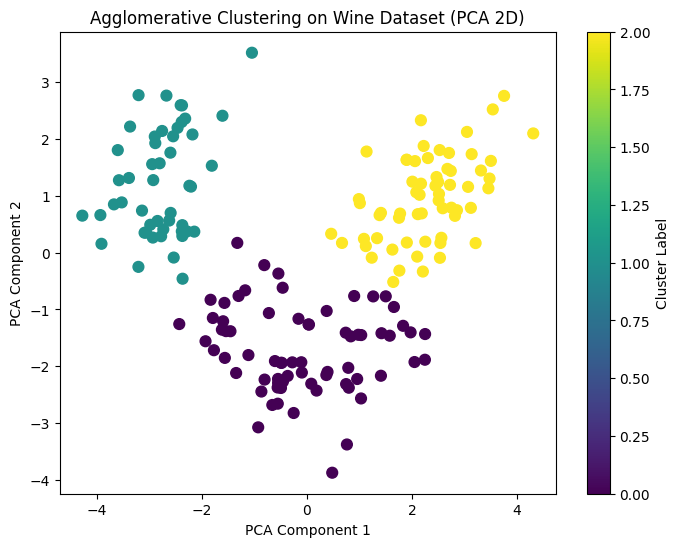

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Step 1: Load Wine dataset
wine = load_wine()
X = wine.data

# Step 2: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X_pca)

# Step 5: Visualization
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=labels,
            cmap='viridis',
            s=60)

plt.title("Agglomerative Clustering on Wine Dataset (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster Label")

plt.show()

Question 10: You are working as a data analyst at an e-commerce company. The
marketing team wants to segment customers based on their purchasing behavior to run
targeted promotions. The dataset contains customer demographics and their product
purchase history across categories.
Describe your real-world data science workflow using clustering:
● Which clustering algorithm(s) would you use and why?
● How would you preprocess the data (missing values, scaling)?
● How would you determine the number of clusters?
● How would the marketing team benefit from your clustering analysis?
(Include your Python code and output in the code box below.)

1. Which clustering algorithm(s) would you use and why?

For e-commerce customer segmentation, I would mainly use:

- K-Means Clustering
   - Works well for large datasets
   -Produces clearly interpretable “customer groups”
   - Efficient and widely used in marketing segmentation
- DBSCAN (optional comparison)
   - Useful if there are outliers (very unusual customers)
   - Does not require number of clusters in advance
   - Captures irregular-shaped clusters
- Final choice in most business cases: K-Means (primary), DBSCAN (for anomaly detection)


2. How would you preprocess the data?

Typical preprocessing steps:

(a) Handling missing values
- Numerical: fill with mean/median
- Categorical: fill with mode
- Or drop rows if too sparse

(b) Encoding categorical variables
- Convert gender, region, etc. using:
- Label Encoding / One-Hot Encoding

c) Feature scaling (VERY important)
- Use StandardScaler
- Because clustering depends on distance

(d) Feature selection / engineering
- Total spend per category
- Total purchases
- Average order value
- Recency / frequency / monetary (RFM features)

3. How to determine number of clusters?

I would use:

- Elbow Method (WCSS/Inertia)
- Silhouette Score
- Business interpretability check

Choose K where:

- Elbow curve bends
- Silhouette score is highest
- Clusters make business sense (e.g., VIP, regular, low-value customers)

4. How marketing benefits from clustering?

Clustering helps marketing team by enabling:

- Targeted promotions

    - High spenders → premium offers
   - Low spenders → discount campaigns
 - Product recommendation strategies

   - Electronics buyers → cross-sell accessories  

- Customer value identification

   - VIP customers → loyalty programs   
- Retention strategies

    - At-risk customers → re-engagement campaigns   
- Better decision making

   - Instead of one-size-fits-all marketing    

Silhouette Score: 0.756
Cluster Counts:
Cluster
1    125
2    125
0    125
3    125
Name: count, dtype: int64


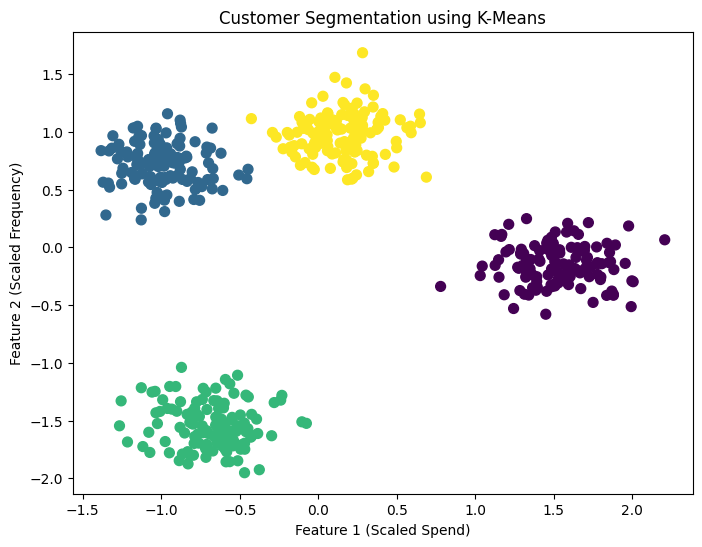

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

# -----------------------------
# Step 1: Simulated customer data (purchase behavior)
# -----------------------------
X, _ = make_blobs(n_samples=500,
                  centers=4,
                  cluster_std=1.2,
                  random_state=42)

df = pd.DataFrame(X, columns=["Total_Spend", "Purchase_Frequency"])

# -----------------------------
# Step 2: Preprocessing (Scaling)
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# -----------------------------
# Step 3: Elbow Method
# -----------------------------
wcss = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# -----------------------------
# Step 4: Fit final model (K=4 assumed optimal)
# -----------------------------
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels

# -----------------------------
# Step 5: Evaluation
# -----------------------------
score = silhouette_score(X_scaled, labels)

print("Silhouette Score:", round(score, 3))
print("Cluster Counts:")
print(df["Cluster"].value_counts())

# -----------------------------
# Step 6: Visualization
# -----------------------------
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=labels, cmap="viridis", s=50)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Feature 1 (Scaled Spend)")
plt.ylabel("Feature 2 (Scaled Frequency)")
plt.show()